In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

shp_path = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp")

print("File exists:", shp_path.exists())
print("Path:", shp_path)

# 한글 속성 깨짐 방지용 fallback
try:
    gdf = gpd.read_file(shp_path)
except UnicodeDecodeError:
    gdf = gpd.read_file(shp_path, encoding="cp949")

print("\n========== Basic Info ==========")
print("Number of features:", len(gdf))
print("CRS:", gdf.crs)
print("Geometry types:")
print(gdf.geometry.geom_type.value_counts())

print("\n========== Bounds ==========")
print(gdf.total_bounds)  # xmin, ymin, xmax, ymax

print("\n========== Columns ==========")
for i, col in enumerate(gdf.columns):
    print(f"{i:02d}: {col} | dtype={gdf[col].dtype}")

print("\n========== First 5 Rows ==========")
pd.set_option("display.max_columns", None)
print(gdf.head())

print("\n========== Missing Ratio by Column ==========")
missing = gdf.drop(columns="geometry").isna().mean().sort_values(ascending=False)
print(missing.head(30))

print("\n========== Numeric Columns Summary ==========")
numeric_cols = gdf.drop(columns="geometry").select_dtypes(include=["number"]).columns.tolist()
print("Numeric columns:", numeric_cols)

if len(numeric_cols) > 0:
    print(gdf[numeric_cols].describe().T)

print("\n========== Area Check ==========")
# CRS가 meter 기반이면 바로 area 계산 가능
if gdf.crs is not None:
    if gdf.crs.to_epsg() != 32652:
        gdf_utm = gdf.to_crs("EPSG:32652")
    else:
        gdf_utm = gdf.copy()

    gdf_utm["geom_area_m2"] = gdf_utm.geometry.area
    print(gdf_utm["geom_area_m2"].describe())
else:
    print("CRS is None. Need to set CRS before area calculation.")

File exists: True
Path: /mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp

========== Basic Info ==========
Number of features: 687229
CRS: EPSG:5174
Geometry types:
Polygon         687223
MultiPolygon         6
Name: count, dtype: int64

========== Bounds ==========
[179398.234 436464.44  219590.825 466311.22 ]

========== Columns ==========
00: A0 | dtype=int32
01: A1 | dtype=object
02: A2 | dtype=object
03: A3 | dtype=object
04: A4 | dtype=object
05: A5 | dtype=object
06: A6 | dtype=object
07: A7 | dtype=object
08: A8 | dtype=object
09: A9 | dtype=object
10: A10 | dtype=object
11: A11 | dtype=object
12: A12 | dtype=float64
13: A13 | dtype=object
14: A14 | dtype=float64
15: A15 | dtype=float64
16: A16 | dtype=float64
17: A17 | dtype=float64
18: A18 | dtype=float64
19: A19 | dtype=object
20: A20 | dtype=object
21: A21 | dtype=object
22: A22 | dtype=datetime64[ms]
23: geometry | dtype=geometry

========== First 5 Rows ==========
      A0            

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

shp_path = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp")
out_dir = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/check")
out_dir.mkdir(parents=True, exist_ok=True)

try:
    gdf = gpd.read_file(shp_path)
except UnicodeDecodeError:
    gdf = gpd.read_file(shp_path, encoding="cp949")

print("CRS:", gdf.crs)
print("Rows:", len(gdf))
print("Columns:", list(gdf.columns))

# geometry 제외
df = gdf.drop(columns="geometry").copy()

print("\n========== First 10 rows transposed ==========")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 20)
print(df.head(10).T)

print("\n========== Column profiling ==========")

records = []

for col in df.columns:
    s = df[col]
    non_null = s.notna().sum()
    non_null_ratio = non_null / len(s)

    # 문자열 공백 제거
    s_str = s.astype(str).str.strip()
    s_str = s_str.replace({"": np.nan, "nan": np.nan, "None": np.nan})

    # 숫자 변환 가능성 확인
    s_num = pd.to_numeric(s_str, errors="coerce")
    numeric_ratio = s_num.notna().sum() / max(non_null, 1)

    top_values = s_str.value_counts(dropna=True).head(10)

    rec = {
        "column": col,
        "dtype": str(s.dtype),
        "non_null": int(non_null),
        "non_null_ratio": float(non_null_ratio),
        "unique_count": int(s_str.nunique(dropna=True)),
        "numeric_ratio": float(numeric_ratio),
        "num_min": float(s_num.min()) if s_num.notna().any() else None,
        "num_median": float(s_num.median()) if s_num.notna().any() else None,
        "num_mean": float(s_num.mean()) if s_num.notna().any() else None,
        "num_max": float(s_num.max()) if s_num.notna().any() else None,
        "top_values": " | ".join([f"{idx}:{val}" for idx, val in top_values.items()])
    }
    records.append(rec)

profile = pd.DataFrame(records)
profile.to_csv(out_dir / "building_column_profile.csv", index=False, encoding="utf-8-sig")

print(profile[[
    "column", "dtype", "non_null_ratio", "unique_count",
    "numeric_ratio", "num_min", "num_median", "num_mean", "num_max",
    "top_values"
]].to_string(index=False))

print("\nSaved:", out_dir / "building_column_profile.csv")

CRS: EPSG:5174
Rows: 687229
Columns: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'geometry']

========== First 10 rows transposed ==========
                                0                             1  \
A0                          24920                         24921   
A1   1988197154764542851400000000  1988197134104543067200000000   
A2            1111010100100010000           1111010100100010000   
A3                     1111010100                    1111010100   
A4       ¼­¿ïÆ¯º°½Ã Á¾·Î±¸ Ã»¿îµ¿      ¼­¿ïÆ¯º°½Ã Á¾·Î±¸ Ã»¿îµ¿   
A5                              1                             1   
A6                              1                             1   
A7                           ÀÏ¹Ý                          ÀÏ¹Ý   
A8                          02000                         02000   
A9                       °øµ¿ÁÖÅÃ                      °øµ¿ÁÖÅÃ   
A10           

In [3]:
import shutil
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.enums import MergeAlg
from rasterio.transform import from_origin
from scipy.io import savemat


# ============================================================
# Path settings
# ============================================================

BASE_DIR = Path("/mnt/disk1/workspace_jym/LCZ/data")

GT_50M_PATH = BASE_DIR / "GT" / "seoul_LCZ.tif"

BUILDING_SHP = (
    BASE_DIR
    / "Building"
    / "AL_11_D010_20200502"
    / "AL_11_D010_20200502.shp"
)

# 기존 RS-only norm
RS_NORM_DIR = BASE_DIR / "Satellite" / "processed" / "norm"

# building raster 결과
BUILDING_OUT_DIR = BASE_DIR / "Building" / "processed"
BUILDING_10M_DIR = BUILDING_OUT_DIR / "10m"

# RS + building norm 결과
RS_BUILDING_NORM_DIR = BASE_DIR / "Satellite" / "processed" / "norm_rs_building"

TARGET_CRS = "EPSG:32652"
TARGET_RES = 10.0
NODATA_OUT = 0.0

# QGIS 확인 결과: A10 = 층수로 사용
STORY_COL = "A10"


# ============================================================
# Utility
# ============================================================

def normalize_positive(arr: np.ndarray) -> np.ndarray:
    """
    0은 no-building/background로 유지.
    양수 값만 0~1로 min-max normalization.
    """
    arr = arr.astype(np.float32)
    arr[~np.isfinite(arr)] = 0.0

    norm = np.zeros_like(arr, dtype=np.float32)

    valid = arr > 0
    if valid.sum() == 0:
        return norm

    vmin = float(arr[valid].min())
    vmax = float(arr[valid].max())

    if vmax == vmin:
        norm[valid] = 1.0
    else:
        norm[valid] = (arr[valid] - vmin) / (vmax - vmin)

    return norm.astype(np.float32)


def write_tif(path: Path, arr: np.ndarray, profile: dict):
    path.parent.mkdir(parents=True, exist_ok=True)

    out_profile = profile.copy()
    out_profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=NODATA_OUT,
        compress="lzw",
    )

    with rasterio.open(path, "w", **out_profile) as dst:
        dst.write(arr.astype(np.float32), 1)


def print_arr_stats(name: str, arr: np.ndarray):
    valid = arr > 0
    print(f"\n{name}")
    print("  shape:", arr.shape)
    print("  positive pixels:", int(valid.sum()))
    print("  positive ratio:", f"{valid.sum() / arr.size * 100:.2f}%")
    if valid.sum() > 0:
        print("  min:", float(arr[valid].min()))
        print("  median:", float(np.median(arr[valid])))
        print("  mean:", float(arr[valid].mean()))
        print("  max:", float(arr[valid].max()))


# ============================================================
# 1. Make target 10m grid from 50m LCZ GT
# ============================================================

with rasterio.open(GT_50M_PATH) as gt:
    gt_bounds = gt.bounds
    gt_crs = gt.crs

    target_width = gt.width * 5
    target_height = gt.height * 5

    target_transform = from_origin(
        gt_bounds.left,
        gt_bounds.top,
        TARGET_RES,
        TARGET_RES,
    )

target_profile = {
    "driver": "GTiff",
    "height": target_height,
    "width": target_width,
    "count": 1,
    "dtype": "float32",
    "crs": gt_crs,
    "transform": target_transform,
    "nodata": NODATA_OUT,
}

print("========== Target 10m Grid ==========")
print("CRS:", gt_crs)
print("Width:", target_width)
print("Height:", target_height)
print("Bounds:", gt_bounds)
print("Transform:", target_transform)


# ============================================================
# 2. Load and preprocess building shapefile
# ============================================================

print("\n========== Load Building SHP ==========")
print("SHP:", BUILDING_SHP)

if not BUILDING_SHP.exists():
    raise FileNotFoundError(f"Building SHP not found: {BUILDING_SHP}")

try:
    gdf = gpd.read_file(BUILDING_SHP)
except UnicodeDecodeError:
    gdf = gpd.read_file(BUILDING_SHP, encoding="cp949")

print("Original CRS:", gdf.crs)
print("Original feature count:", len(gdf))

if STORY_COL not in gdf.columns:
    raise KeyError(f"{STORY_COL} not found. Available columns: {list(gdf.columns)}")

# CRS 변환
gdf = gdf.to_crs(TARGET_CRS)

# LCZ extent 기준으로 clip
xmin, ymin, xmax, ymax = gt_bounds.left, gt_bounds.bottom, gt_bounds.right, gt_bounds.top
gdf = gdf.cx[xmin:xmax, ymin:ymax].copy()

print("Clipped feature count:", len(gdf))

# geometry 정리
gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()
gdf["geometry"] = gdf.geometry.buffer(0)
gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()

# 면적 계산
gdf["area_m2"] = gdf.geometry.area.astype(np.float32)

# 층수 숫자 변환
gdf["story"] = pd.to_numeric(gdf[STORY_COL], errors="coerce").fillna(0).astype(np.float32)
gdf.loc[gdf["story"] < 0, "story"] = 0

# 유효하지 않은 면적 제거
gdf = gdf[gdf["area_m2"] > 0].copy()

print("Valid feature count:", len(gdf))
print("\nArea stats:")
print(gdf["area_m2"].describe())
print("\nStory stats:")
print(gdf["story"].describe())
print("Story positive ratio:", f"{(gdf['story'] > 0).mean() * 100:.2f}%")


# ============================================================
# 3. Rasterize building area layer
# ============================================================
# 논문식 horizontal component:
# polygon 면적을 계산한 뒤 10m raster layer로 변환.
#
# 구현:
# 각 building polygon의 geometry.area 값을 raster에 burn.
# 한 10m cell에 여러 building이 겹치면 면적값을 합산.
# ============================================================

print("\n========== Rasterize Building Area Layer ==========")

area_shapes = (
    (geom, float(area))
    for geom, area in zip(gdf.geometry, gdf["area_m2"])
)

area_raster = rasterize(
    shapes=area_shapes,
    out_shape=(target_height, target_width),
    transform=target_transform,
    fill=0.0,
    dtype="float32",
    merge_alg=MergeAlg.add,
    all_touched=False,
)

area_tif = BUILDING_10M_DIR / "09_building_area_10m.tif"
write_tif(area_tif, area_raster, target_profile)
print("Saved:", area_tif)
print_arr_stats("building_area_10m", area_raster)


# ============================================================
# 4. Rasterize building story layer
# ============================================================
# 논문식 vertical component:
# 서울에서는 number of stories 사용.
#
# 구현:
# 같은 10m cell에 여러 building이 들어갈 수 있으므로
# area-weighted mean story로 계산.
# ============================================================

print("\n========== Rasterize Building Story Layer ==========")

story_weighted_shapes = (
    (geom, float(area * story))
    for geom, area, story in zip(gdf.geometry, gdf["area_m2"], gdf["story"])
    if story > 0
)

area_for_story_shapes = (
    (geom, float(area))
    for geom, area, story in zip(gdf.geometry, gdf["area_m2"], gdf["story"])
    if story > 0
)

story_weighted_sum = rasterize(
    shapes=story_weighted_shapes,
    out_shape=(target_height, target_width),
    transform=target_transform,
    fill=0.0,
    dtype="float32",
    merge_alg=MergeAlg.add,
    all_touched=False,
)

area_for_story_sum = rasterize(
    shapes=area_for_story_shapes,
    out_shape=(target_height, target_width),
    transform=target_transform,
    fill=0.0,
    dtype="float32",
    merge_alg=MergeAlg.add,
    all_touched=False,
)

story_raster = np.zeros_like(story_weighted_sum, dtype=np.float32)
valid_story = area_for_story_sum > 0
story_raster[valid_story] = story_weighted_sum[valid_story] / area_for_story_sum[valid_story]

story_tif = BUILDING_10M_DIR / "10_building_story_10m.tif"
write_tif(story_tif, story_raster, target_profile)
print("Saved:", story_tif)
print_arr_stats("building_story_10m", story_raster)


# ============================================================
# 5. Normalize and save MAT
# ============================================================

print("\n========== Create RS + Building norm folder ==========")
RS_BUILDING_NORM_DIR.mkdir(parents=True, exist_ok=True)

# 기존 RS b1~b8 복사
rs_mat_paths = sorted(RS_NORM_DIR.glob("b*_norm.mat"))

if len(rs_mat_paths) == 0:
    raise FileNotFoundError(f"No RS norm files found in {RS_NORM_DIR}")

for p in rs_mat_paths:
    dst = RS_BUILDING_NORM_DIR / p.name
    shutil.copy2(p, dst)
    print("Copied:", p.name, "->", dst)

# b9, b10 생성
area_norm = normalize_positive(area_raster)
story_norm = normalize_positive(story_raster)

savemat(RS_BUILDING_NORM_DIR / "b9_norm.mat", {"norm": area_norm.astype(np.float32)})
savemat(RS_BUILDING_NORM_DIR / "b10_norm.mat", {"norm": story_norm.astype(np.float32)})

print("Saved:", RS_BUILDING_NORM_DIR / "b9_norm.mat")
print("Saved:", RS_BUILDING_NORM_DIR / "b10_norm.mat")

print_arr_stats("building_area_norm", area_norm)
print_arr_stats("building_story_norm", story_norm)

print("\n========== Done ==========")
print("Building 10m GeoTIFFs:", BUILDING_10M_DIR)
print("RS + Building norm MATs:", RS_BUILDING_NORM_DIR)

========== Target 10m Grid ==========
CRS: EPSG:32652
Width: 4495
Height: 4245
Bounds: BoundingBox(left=300630.0, bottom=4137650.0, right=345580.0, top=4180100.0)
Transform: | 10.00, 0.00, 300630.00|
| 0.00,-10.00, 4180100.00|
| 0.00, 0.00, 1.00|

========== Load Building SHP ==========
SHP: /mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp
Original CRS: EPSG:5174
Original feature count: 687229
Clipped feature count: 687229
Valid feature count: 687229

Area stats:
count    687229.000000
mean        149.677338
std         945.870178
min           0.000005
25%          61.572281
50%          94.782806
75%         140.880310
max      727228.250000
Name: area_m2, dtype: float64

Story stats:
count    687229.000000
mean         14.549993
std          10.968705
min           0.000000
25%          11.000000
50%          11.000000
75%          21.000000
max          99.000000
Name: story, dtype: float64
Story positive ratio: 80.25%

========== Rasterize Bui

========== Load building data ==========
Fix invalid geometries: 43
Total buildings: 687,229
Valid story buildings: 551,471 (80.25%)
Missing story buildings: 135,758 (19.75%)
CRS: EPSG:5174


,value
building_total_count,6.872290e+05
building_valid_story_count,5.514710e+05
building_missing_story_count,1.357580e+05
building_valid_story_ratio_count,8.024559e-01
building_missing_story_ratio_count,1.975441e-01
building_total_area_m2,1.028665e+08
building_valid_story_area_m2,9.200883e+07
building_missing_story_area_m2,1.085771e+07
building_valid_story_ratio_area,8.944485e-01
building_missing_story_ratio_area,1.055515e-01


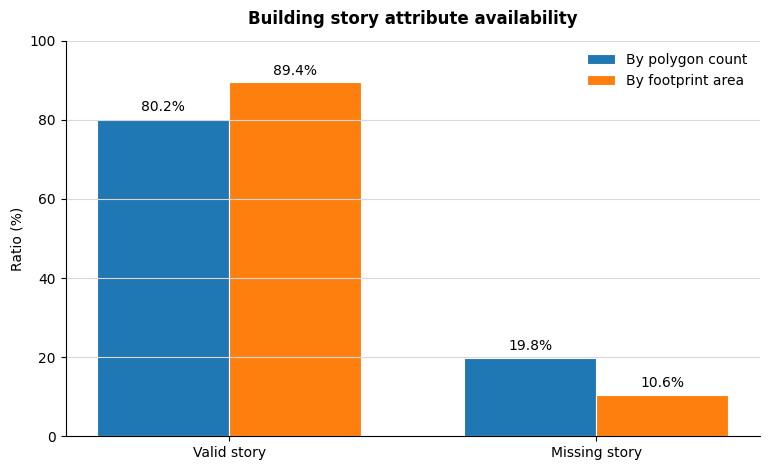

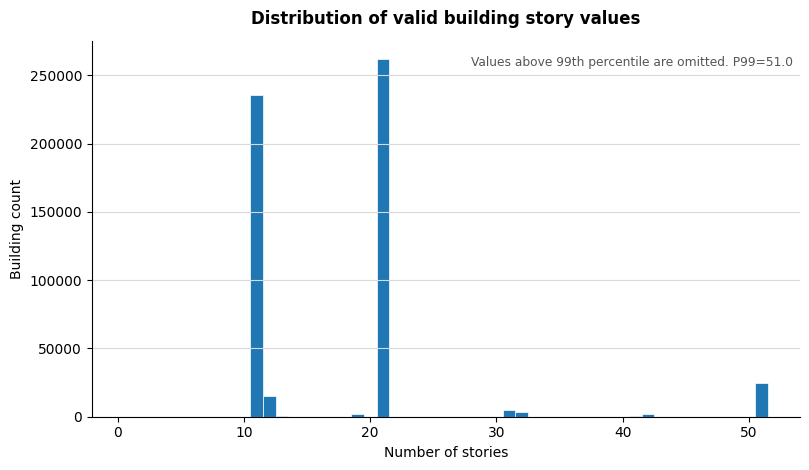

========== Rasterize building story status ==========
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_missingness_notebook/building_story_status_grid.tif


,value
grid_total_valid_cells,41546.000000
grid_no_building_cells,25357.000000
grid_valid_story_only_cells,9065.000000
grid_missing_story_only_cells,717.000000
grid_mixed_valid_missing_cells,6407.000000
grid_building_cells,16189.000000
grid_cells_with_valid_story,15472.000000
grid_cells_with_missing_story,7124.000000
grid_building_cell_ratio,0.389664
grid_valid_story_among_building_cells_ratio,0.955711


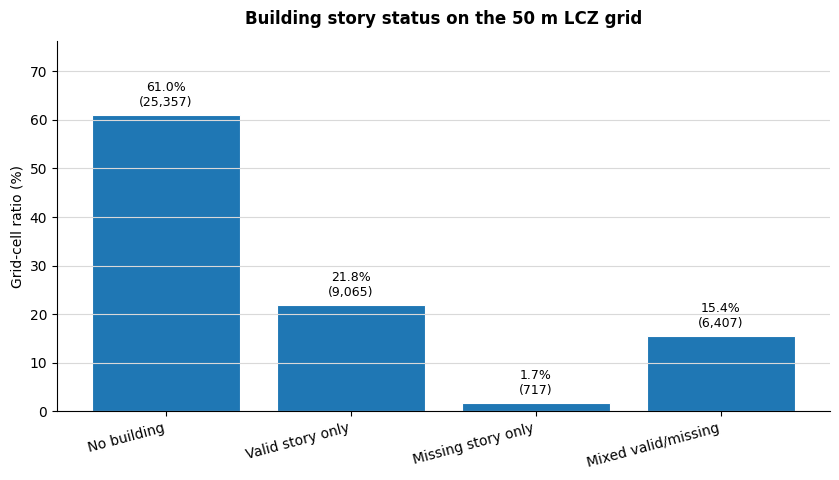

,class_code,class_label,total_cells,building_cells,valid_story_only_cells,missing_story_only_cells,mixed_valid_missing_cells,cells_with_valid_story,cells_with_missing_story,building_cell_ratio,valid_story_among_building_cells_ratio,missing_story_among_building_cells_ratio,missing_only_among_building_cells_ratio,mixed_among_building_cells_ratio
0,1,LCZ1,322,320,230,2,88,318,90,0.993789,0.993750,0.281250,0.006250,0.275000
1,2,LCZ2,2052,2052,1503,0,549,2052,549,1.000000,1.000000,0.267544,0.000000,0.267544
2,3,LCZ3,6219,6219,2977,0,3242,6219,3242,1.000000,1.000000,0.521306,0.000000,0.521306
3,4,LCZ4,5155,5067,3148,60,1859,5007,1919,0.982929,0.988159,0.378725,0.011841,0.366884
4,5,LCZ5,815,690,466,10,214,680,224,0.846626,0.985507,0.324638,0.014493,0.310145
5,6,LCZ6,925,910,535,3,372,907,375,0.983784,0.996703,0.412088,0.003297,0.408791
6,8,LCZ8,899,376,101,239,36,137,275,0.418242,0.364362,0.731383,0.635638,0.095745
7,101,LCZA,13410,72,9,54,9,18,63,0.005369,0.250000,0.875000,0.750000,0.125000
8,102,LCZB,4565,465,94,335,36,130,371,0.101862,0.279570,0.797849,0.720430,0.077419
9,104,LCZD,4637,15,1,12,2,3,14,0.003235,0.200000,0.933333,0.800000,0.133333


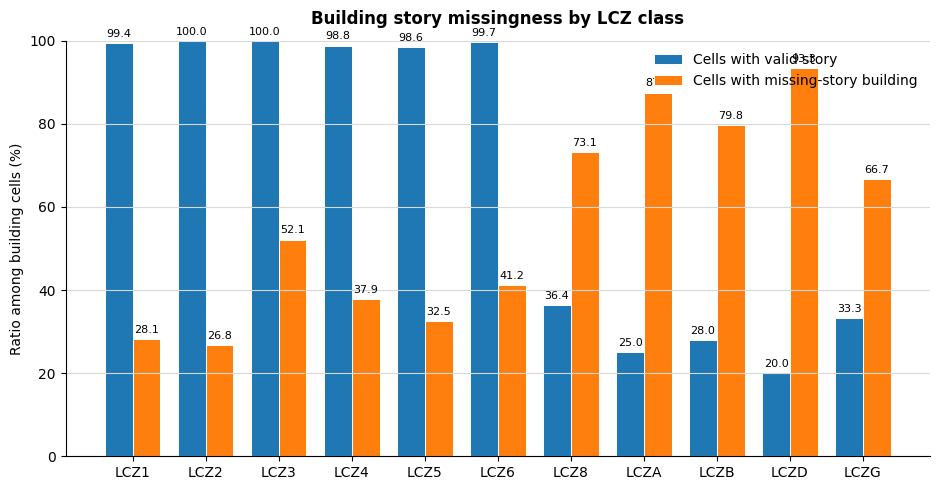

/tmp/ipykernel_4092213/3082093855.py:548: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


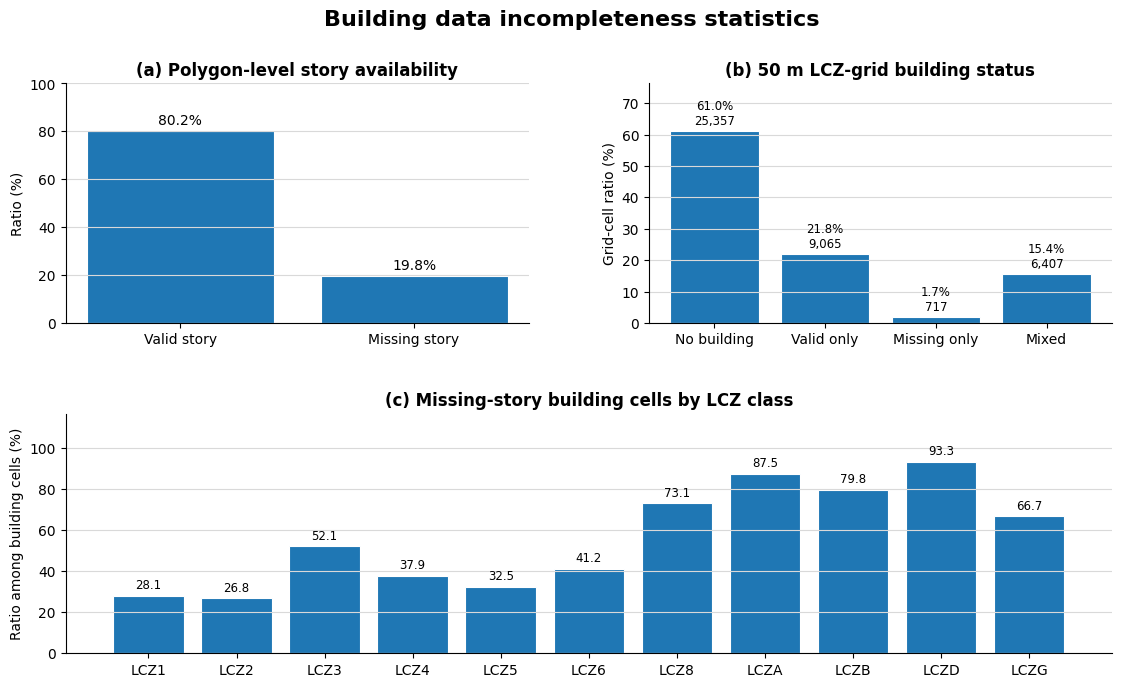

Saved outputs to: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_missingness_notebook


In [6]:
# ============================================================
# Building data missingness statistics & visualization
# - story_col(A10) 기준 층수 정보 누락률 계산
# - polygon count / footprint area 기준 누락률
# - 50 m LCZ grid 기준 누락 상태
# - LCZ class별 missing-story building cell 비율
# ============================================================

from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
BUILDING_SHP = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp")
STORY_COL = "A10"

# 50 m LCZ grid template
TEMPLATE_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# LCZ class별 누락률을 어떤 LCZ map 기준으로 볼지 선택
# 1) reference/test GT 기준으로 보고 싶으면:
LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# 2) 서울 전역 Proposed LCZ map 기준으로 보고 싶으면 위 줄 대신 아래 사용:
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw.tif")
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw_maj3.tif")

OUT_DIR = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_missingness_notebook")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300

LCZ_LABEL = {
    1: "LCZ1", 2: "LCZ2", 3: "LCZ3", 4: "LCZ4", 5: "LCZ5", 6: "LCZ6",
    7: "LCZ7", 8: "LCZ8", 9: "LCZ9", 10: "LCZ10",
    101: "LCZA", 102: "LCZB", 103: "LCZC", 104: "LCZD",
    105: "LCZE", 106: "LCZF", 107: "LCZG"
}

CLASS_CODES = [1, 2, 3, 4, 5, 6, 8, 101, 102, 104, 107]

# ------------------------------------------------------------
# 1. Load building data and define missing story
# ------------------------------------------------------------
print("========== Load building data ==========")
gdf = gpd.read_file(BUILDING_SHP)
gdf = gdf[gdf.geometry.notna()].copy()
gdf = gdf[~gdf.geometry.is_empty].copy()

# invalid geometry 보정
invalid = ~gdf.geometry.is_valid
if invalid.any():
    print(f"Fix invalid geometries: {invalid.sum():,}")
    gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

# story column numeric 변환
gdf["_story"] = pd.to_numeric(gdf[STORY_COL], errors="coerce")

# A10이 NaN / 비숫자 / 0 이하이면 missing, A10 > 0이면 valid
valid_story = gdf["_story"].notna() & (gdf["_story"] > 0)
missing_story = ~valid_story

print(f"Total buildings: {len(gdf):,}")
print(f"Valid story buildings: {valid_story.sum():,} ({valid_story.mean()*100:.2f}%)")
print(f"Missing story buildings: {missing_story.sum():,} ({missing_story.mean()*100:.2f}%)")
print(f"CRS: {gdf.crs}")
# ------------------------------------------------------------
# 2. Polygon-level missingness statistics
#    - count 기준
#    - footprint area 기준
# ------------------------------------------------------------
if gdf.crs is not None and gdf.crs.is_projected:
    area_m2 = gdf.geometry.area.to_numpy(dtype=np.float64)
else:
    # 좌표계가 geographic이면 면적 계산용으로 EPSG:5186 변환
    area_m2 = gdf.to_crs("EPSG:5186").geometry.area.to_numpy(dtype=np.float64)

total_count = len(gdf)
valid_count = int(valid_story.sum())
missing_count = int(missing_story.sum())

total_area = float(np.nansum(area_m2))
valid_area = float(np.nansum(area_m2[valid_story.to_numpy()]))
missing_area = float(np.nansum(area_m2[missing_story.to_numpy()]))

summary = {
    "building_total_count": total_count,
    "building_valid_story_count": valid_count,
    "building_missing_story_count": missing_count,
    "building_valid_story_ratio_count": valid_count / total_count,
    "building_missing_story_ratio_count": missing_count / total_count,
    "building_total_area_m2": total_area,
    "building_valid_story_area_m2": valid_area,
    "building_missing_story_area_m2": missing_area,
    "building_valid_story_ratio_area": valid_area / total_area,
    "building_missing_story_ratio_area": missing_area / total_area,
    "story_min_valid": float(gdf.loc[valid_story, "_story"].min()),
    "story_median_valid": float(gdf.loc[valid_story, "_story"].median()),
    "story_mean_valid": float(gdf.loc[valid_story, "_story"].mean()),
    "story_p95_valid": float(gdf.loc[valid_story, "_story"].quantile(0.95)),
    "story_max_valid": float(gdf.loc[valid_story, "_story"].max()),
}

pd.DataFrame([summary]).to_csv(OUT_DIR / "building_missing_summary.csv", index=False, encoding="utf-8-sig")

with open(OUT_DIR / "building_missing_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))
# ------------------------------------------------------------
# 3. Plot 1: count/area 기준 story availability
# ------------------------------------------------------------
categories = ["Valid story", "Missing story"]

count_values = [
    summary["building_valid_story_ratio_count"] * 100,
    summary["building_missing_story_ratio_count"] * 100,
]

area_values = [
    summary["building_valid_story_ratio_area"] * 100,
    summary["building_missing_story_ratio_area"] * 100,
]

x = np.arange(len(categories))
width = 0.36

fig, ax = plt.subplots(figsize=(7.8, 4.8))

bars1 = ax.bar(
    x - width / 2,
    count_values,
    width,
    label="By polygon count",
    edgecolor="white",
    linewidth=0.8,
)

bars2 = ax.bar(
    x + width / 2,
    area_values,
    width,
    label="By footprint area",
    edgecolor="white",
    linewidth=0.8,
)

ax.set_xticks(x, categories)
ax.set_ylim(0, 100)
ax.set_ylabel("Ratio (%)")
ax.set_title("Building story attribute availability", fontweight="bold", pad=12)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 1.2,
            f"{h:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()
plt.savefig(OUT_DIR / "building_polygon_missing_by_count_area.png", dpi=DPI, bbox_inches="tight")
plt.show()
# ------------------------------------------------------------
# 4. Plot 2: valid story 값 분포
# ------------------------------------------------------------
story_values = gdf.loc[valid_story, "_story"].dropna().to_numpy(dtype=np.float64)
story_values = story_values[story_values > 0]

p99 = np.percentile(story_values, 99)
max_plot = int(np.ceil(p99))
story_plot = story_values[story_values <= max_plot]

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bins = np.arange(0.5, max_plot + 1.5, 1)
ax.hist(story_plot, bins=bins, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Number of stories")
ax.set_ylabel("Building count")
ax.set_title("Distribution of valid building story values", fontweight="bold", pad=12)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.99,
    0.96,
    f"Values above 99th percentile are omitted. P99={p99:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.8,
    color="#555555",
)

plt.tight_layout()
plt.savefig(OUT_DIR / "building_story_distribution.png", dpi=DPI, bbox_inches="tight")
plt.show()
# ------------------------------------------------------------
# 5. Rasterize valid/missing building story status to 50 m LCZ grid
# ------------------------------------------------------------
print("========== Rasterize building story status ==========")

with rasterio.open(TEMPLATE_TIF) as src:
    template_profile = src.profile.copy()
    template_shape = (src.height, src.width)
    template_transform = src.transform
    template_crs = src.crs
    template_arr = src.read(1)
    template_nodata = src.nodata

if gdf.crs != template_crs:
    gdf_grid = gdf.to_crs(template_crs)
else:
    gdf_grid = gdf.copy()

total_shapes = ((geom, 1) for geom in gdf_grid.geometry)
valid_shapes = ((geom, 1) for geom in gdf_grid.loc[valid_story].geometry)
missing_shapes = ((geom, 1) for geom in gdf_grid.loc[missing_story].geometry)

has_building = rasterize(
    total_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_valid_story = rasterize(
    valid_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_missing_story = rasterize(
    missing_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

# status code:
# 0 = no building
# 1 = valid-story building only
# 2 = missing-story building only
# 3 = mixed valid/missing buildings
status = np.zeros(template_shape, dtype=np.uint8)
status[(has_building == 1) & (has_valid_story == 1) & (has_missing_story == 0)] = 1
status[(has_building == 1) & (has_valid_story == 0) & (has_missing_story == 1)] = 2
status[(has_building == 1) & (has_valid_story == 1) & (has_missing_story == 1)] = 3

valid_template = np.ones(template_shape, dtype=bool)
if template_nodata is not None:
    valid_template &= template_arr != template_nodata

# save status raster
status_profile = template_profile.copy()
status_profile.update(count=1, dtype="uint8", nodata=255, compress="lzw")

with rasterio.open(OUT_DIR / "building_story_status_grid.tif", "w", **status_profile) as dst:
    dst.write(status, 1)

print("saved:", OUT_DIR / "building_story_status_grid.tif")
# ------------------------------------------------------------
# 6. Grid-level missingness statistics
# ------------------------------------------------------------
total_cells = int(valid_template.sum())

no_building_cells = int(((status == 0) & valid_template).sum())
valid_only_cells = int(((status == 1) & valid_template).sum())
missing_only_cells = int(((status == 2) & valid_template).sum())
mixed_cells = int(((status == 3) & valid_template).sum())

building_cells = valid_only_cells + missing_only_cells + mixed_cells
cells_with_valid_story = valid_only_cells + mixed_cells
cells_with_missing_story = missing_only_cells + mixed_cells

grid_summary = {
    "grid_total_valid_cells": total_cells,
    "grid_no_building_cells": no_building_cells,
    "grid_valid_story_only_cells": valid_only_cells,
    "grid_missing_story_only_cells": missing_only_cells,
    "grid_mixed_valid_missing_cells": mixed_cells,
    "grid_building_cells": building_cells,
    "grid_cells_with_valid_story": cells_with_valid_story,
    "grid_cells_with_missing_story": cells_with_missing_story,
    "grid_building_cell_ratio": building_cells / total_cells if total_cells else 0,
    "grid_valid_story_among_building_cells_ratio": cells_with_valid_story / building_cells if building_cells else 0,
    "grid_missing_story_among_building_cells_ratio": cells_with_missing_story / building_cells if building_cells else 0,
    "grid_missing_only_among_building_cells_ratio": missing_only_cells / building_cells if building_cells else 0,
    "grid_mixed_among_building_cells_ratio": mixed_cells / building_cells if building_cells else 0,
}

summary.update(grid_summary)
pd.DataFrame([summary]).to_csv(OUT_DIR / "building_missing_summary.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame([grid_summary]).T.rename(columns={0: "value"}))
# ------------------------------------------------------------
# 7. Plot 3: 50 m LCZ grid 기준 building/story status
# ------------------------------------------------------------
grid_categories = [
    "No building",
    "Valid story only",
    "Missing story only",
    "Mixed valid/missing",
]

grid_counts = [
    no_building_cells,
    valid_only_cells,
    missing_only_cells,
    mixed_cells,
]

grid_ratios = [c / total_cells * 100 for c in grid_counts]

fig, ax = plt.subplots(figsize=(8.5, 4.9))

x = np.arange(len(grid_categories))
bars = ax.bar(x, grid_ratios, edgecolor="white", linewidth=0.8)

ax.set_xticks(x, grid_categories, rotation=15, ha="right")
ax.set_ylim(0, max(5, max(grid_ratios) * 1.25))
ax.set_ylabel("Grid-cell ratio (%)")
ax.set_title("Building story status on the 50 m LCZ grid", fontweight="bold", pad=12)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, count, ratio in zip(bars, grid_counts, grid_ratios):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(grid_ratios) * 0.02,
        f"{ratio:.1f}%\n({count:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(OUT_DIR / "building_grid_status.png", dpi=DPI, bbox_inches="tight")
plt.show()
# ------------------------------------------------------------
# 8. LCZ class별 missing-story building cell ratio
# ------------------------------------------------------------
with rasterio.open(LCZ_TIF) as src:
    lcz = src.read(1)
    lcz_nodata = src.nodata

valid_lcz = valid_template.copy()
if lcz_nodata is not None:
    valid_lcz &= lcz != lcz_nodata
valid_lcz &= lcz > 0

rows = []

for code in CLASS_CODES:
    mask = valid_lcz & (lcz == code)
    total = int(mask.sum())

    valid_only = int((mask & (status == 1)).sum())
    missing_only = int((mask & (status == 2)).sum())
    mixed = int((mask & (status == 3)).sum())

    bld_cells = valid_only + missing_only + mixed
    cells_valid_story = valid_only + mixed
    cells_missing_story = missing_only + mixed

    rows.append({
        "class_code": code,
        "class_label": LCZ_LABEL.get(code, f"LCZ{code}"),
        "total_cells": total,
        "building_cells": bld_cells,
        "valid_story_only_cells": valid_only,
        "missing_story_only_cells": missing_only,
        "mixed_valid_missing_cells": mixed,
        "cells_with_valid_story": cells_valid_story,
        "cells_with_missing_story": cells_missing_story,
        "building_cell_ratio": bld_cells / total if total else 0,
        "valid_story_among_building_cells_ratio": cells_valid_story / bld_cells if bld_cells else 0,
        "missing_story_among_building_cells_ratio": cells_missing_story / bld_cells if bld_cells else 0,
        "missing_only_among_building_cells_ratio": missing_only / bld_cells if bld_cells else 0,
        "mixed_among_building_cells_ratio": mixed / bld_cells if bld_cells else 0,
    })

lcz_missing_df = pd.DataFrame(rows)
lcz_missing_df.to_csv(OUT_DIR / "building_missing_by_lcz.csv", index=False, encoding="utf-8-sig")

display(lcz_missing_df)
# ------------------------------------------------------------
# 9. Plot 4: LCZ class별 missing-story building cell ratio
# ------------------------------------------------------------
plot_df = lcz_missing_df[lcz_missing_df["building_cells"] > 0].copy()

labels = plot_df["class_label"].tolist()
missing_pct = plot_df["missing_story_among_building_cells_ratio"].to_numpy() * 100
valid_pct = plot_df["valid_story_among_building_cells_ratio"].to_numpy() * 100

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(max(9.5, len(labels) * 0.78), 5.0))

bars1 = ax.bar(
    x - width / 2,
    valid_pct,
    width,
    label="Cells with valid story",
    edgecolor="white",
    linewidth=0.7,
)

bars2 = ax.bar(
    x + width / 2,
    missing_pct,
    width,
    label="Cells with missing-story building",
    edgecolor="white",
    linewidth=0.7,
)

ax.set_xticks(x, labels)
ax.set_ylim(0, 100)
ax.set_ylabel("Ratio among building cells (%)")
ax.set_title("Building story missingness by LCZ class", fontweight="bold", pad=12)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 1.0,
                f"{h:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

plt.tight_layout()
plt.savefig(OUT_DIR / "building_missing_by_lcz.png", dpi=DPI, bbox_inches="tight")
plt.show()
# ------------------------------------------------------------
# 10. 논문용 통합 Figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(13.5, 7.4))
gs = fig.add_gridspec(2, 2, wspace=0.26, hspace=0.38)

# (a) polygon-level count ratio
ax1 = fig.add_subplot(gs[0, 0])
poly_labels = ["Valid story", "Missing story"]
poly_values = [
    summary["building_valid_story_ratio_count"] * 100,
    summary["building_missing_story_ratio_count"] * 100,
]
bars = ax1.bar(poly_labels, poly_values, edgecolor="white", linewidth=0.8)
ax1.set_ylim(0, 100)
ax1.set_ylabel("Ratio (%)")
ax1.set_title("(a) Polygon-level story availability", fontweight="bold")
ax1.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 1.2,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# (b) grid-level status
ax2 = fig.add_subplot(gs[0, 1])
short_grid_labels = ["No building", "Valid only", "Missing only", "Mixed"]
bars = ax2.bar(short_grid_labels, grid_ratios, edgecolor="white", linewidth=0.8)
ax2.set_ylim(0, max(5, max(grid_ratios) * 1.25))
ax2.set_ylabel("Grid-cell ratio (%)")
ax2.set_title("(b) 50 m LCZ-grid building status", fontweight="bold")
ax2.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

for bar, count, ratio in zip(bars, grid_counts, grid_ratios):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(grid_ratios) * 0.02,
        f"{ratio:.1f}%\n{count:,}",
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

# (c) LCZ-wise missing ratio
ax3 = fig.add_subplot(gs[1, :])
bars = ax3.bar(labels, missing_pct, edgecolor="white", linewidth=0.8)
ax3.set_ylim(0, max(5, max(missing_pct) * 1.25))
ax3.set_ylabel("Ratio among building cells (%)")
ax3.set_title("(c) Missing-story building cells by LCZ class", fontweight="bold")
ax3.grid(axis="y", color="#d9d9d9", linewidth=0.8)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

for bar in bars:
    h = bar.get_height()
    if h >= 3:
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            h + max(missing_pct) * 0.02,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

fig.suptitle("Building data incompleteness statistics", fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout()
plt.savefig(OUT_DIR / "building_missing_figure_combined.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved outputs to:", OUT_DIR)

========== Load building data ==========
Fix invalid geometries: 43
Total buildings: 687,229
Valid building floor information: 551,471 (80.25%)
Missing building floor information: 135,758 (19.75%)
CRS: EPSG:5174


,value
building_total_count,6.872290e+05
building_valid_floor_count,5.514710e+05
building_missing_floor_count,1.357580e+05
building_valid_floor_ratio_count,8.024559e-01
building_missing_floor_ratio_count,1.975441e-01
building_total_area_m2,1.028665e+08
building_valid_floor_area_m2,9.200883e+07
building_missing_floor_area_m2,1.085771e+07
building_valid_floor_ratio_area,8.944485e-01
building_missing_floor_ratio_area,1.055515e-01


saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_availability_stacked_paper.png
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_availability_stacked_paper.svg


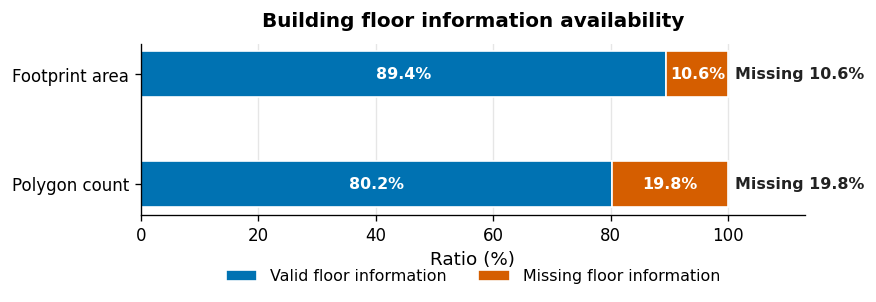

========== Rasterize building floor information status ==========
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_information_status_grid.tif


,value
grid_total_valid_cells,41546.000000
grid_no_building_cells,25357.000000
grid_valid_floor_only_cells,9065.000000
grid_missing_floor_only_cells,717.000000
grid_mixed_valid_missing_floor_cells,6407.000000
grid_building_cells,16189.000000
grid_cells_with_valid_floor,15472.000000
grid_cells_with_missing_floor,7124.000000
grid_building_cell_ratio,0.389664
grid_valid_floor_among_building_cells_ratio,0.955711


saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_grid_status_stacked_paper.png
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_grid_status_stacked_paper.svg


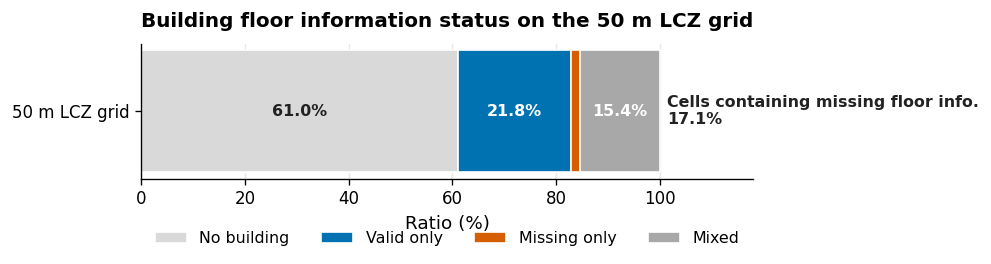

,class_code,class_label,total_cells,building_cells,valid_floor_only_cells,missing_floor_only_cells,mixed_valid_missing_floor_cells,cells_with_valid_floor,cells_with_missing_floor,building_cell_ratio,valid_floor_among_building_cells_ratio,missing_floor_among_building_cells_ratio,missing_only_among_building_cells_ratio,mixed_among_building_cells_ratio
0,1,LCZ1,322,320,230,2,88,318,90,0.993789,0.993750,0.281250,0.006250,0.275000
1,2,LCZ2,2052,2052,1503,0,549,2052,549,1.000000,1.000000,0.267544,0.000000,0.267544
2,3,LCZ3,6219,6219,2977,0,3242,6219,3242,1.000000,1.000000,0.521306,0.000000,0.521306
3,4,LCZ4,5155,5067,3148,60,1859,5007,1919,0.982929,0.988159,0.378725,0.011841,0.366884
4,5,LCZ5,815,690,466,10,214,680,224,0.846626,0.985507,0.324638,0.014493,0.310145
5,6,LCZ6,925,910,535,3,372,907,375,0.983784,0.996703,0.412088,0.003297,0.408791
6,8,LCZ8,899,376,101,239,36,137,275,0.418242,0.364362,0.731383,0.635638,0.095745
7,101,LCZA,13410,72,9,54,9,18,63,0.005369,0.250000,0.875000,0.750000,0.125000
8,102,LCZB,4565,465,94,335,36,130,371,0.101862,0.279570,0.797849,0.720430,0.077419
9,104,LCZD,4637,15,1,12,2,3,14,0.003235,0.200000,0.933333,0.800000,0.133333


saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_missing_by_lcz_paper.png
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_missing_by_lcz_paper.svg


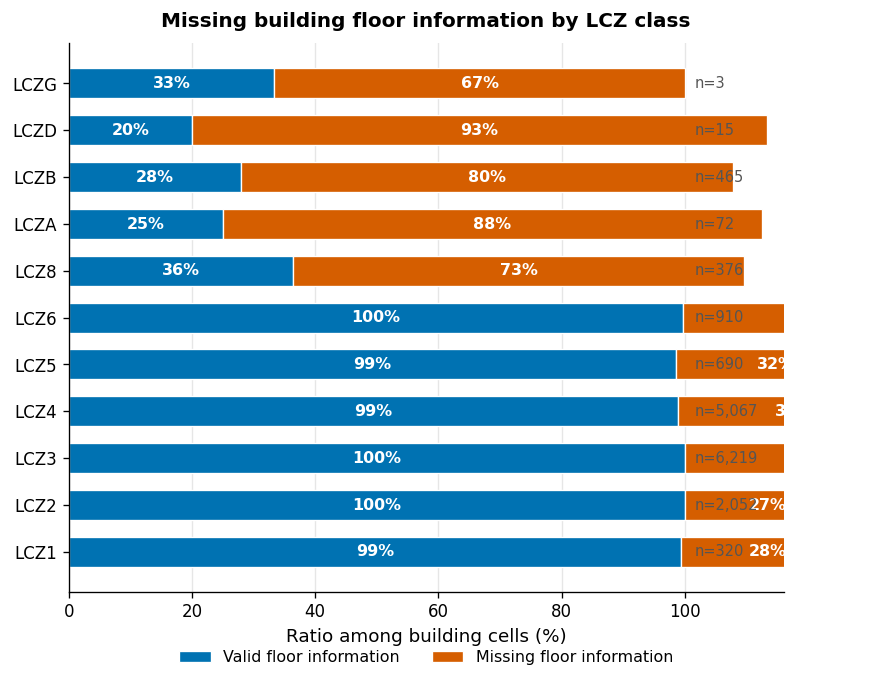

/tmp/ipykernel_4092213/1710035834.py:755: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_missingness_combined_paper.png
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness/building_floor_info_missingness_combined_paper.svg


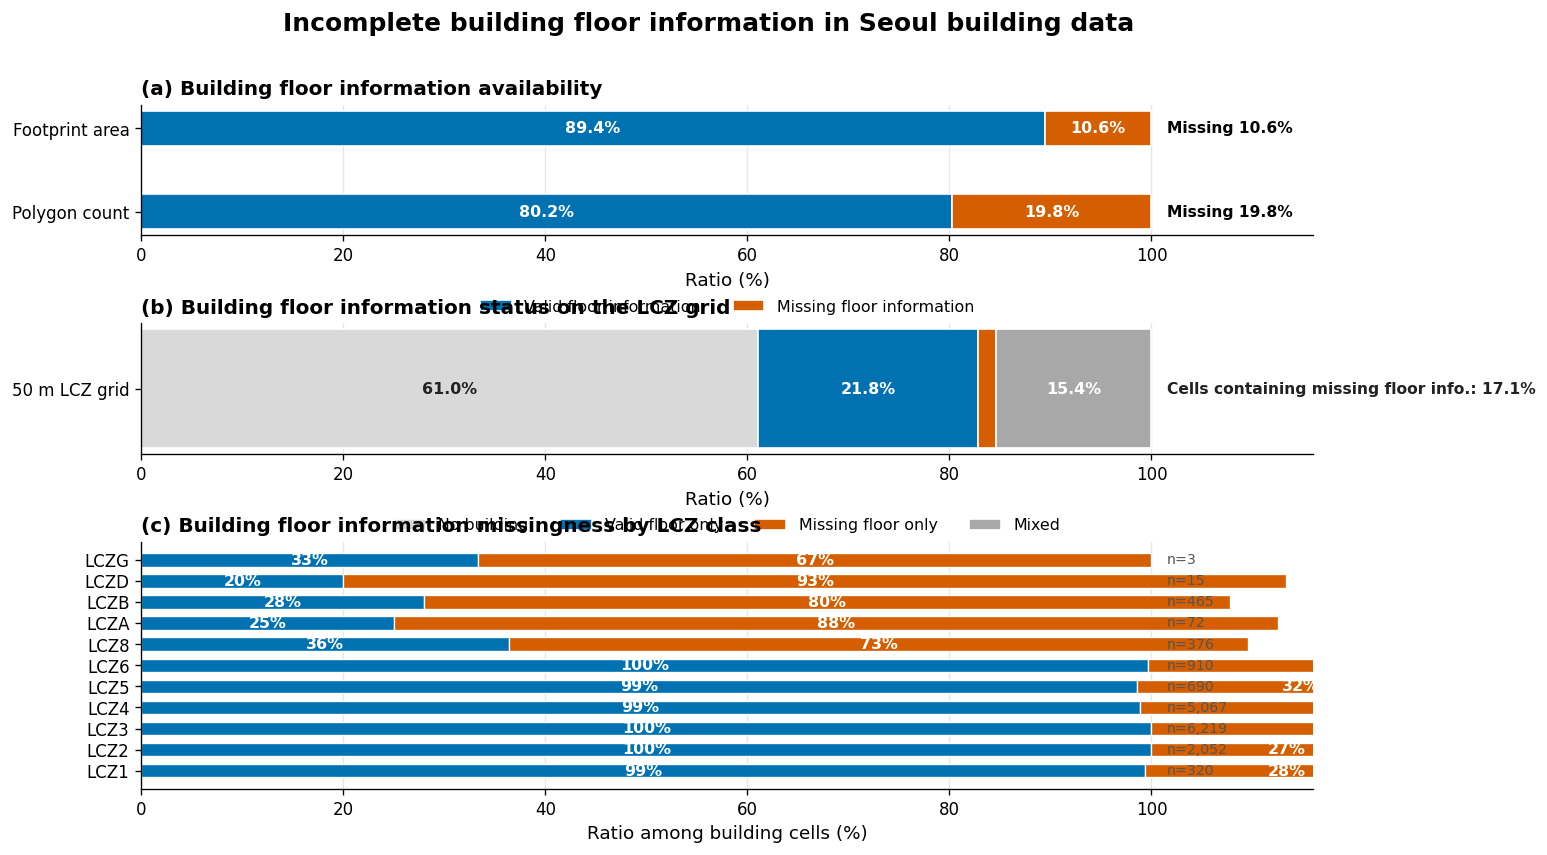

Saved outputs to: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness


In [8]:
# ============================================================
# Building floor information missingness visualization
# - "story" 표현 대신 "building floor information" 사용
# - 논문용 stacked bar style
# - 출력:
#   1) building_floor_info_availability_stacked_paper.png/svg
#   2) building_floor_info_grid_status_stacked_paper.png/svg
#   3) building_floor_info_missing_by_lcz_paper.png/svg
#   4) building_floor_info_missingness_combined_paper.png/svg
#   5) building_floor_information_missingness_summary.csv
#   6) building_floor_information_missingness_by_lcz.csv
# ============================================================

from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
BUILDING_SHP = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp")
FLOOR_COL = "A10"   # building floor information column

TEMPLATE_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# LCZ별 누락률을 어떤 LCZ map 기준으로 볼지 선택
# reference LCZ 기준이면 GT 사용
LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# 서울 전역 예측 map 기준으로 보고 싶으면 아래 중 하나 사용
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw.tif")
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw_maj3.tif")

OUT_DIR = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 400

CLASS_CODES = [1, 2, 3, 4, 5, 6, 8, 101, 102, 104, 107]

LCZ_LABEL = {
    1: "LCZ1", 2: "LCZ2", 3: "LCZ3", 4: "LCZ4", 5: "LCZ5", 6: "LCZ6",
    7: "LCZ7", 8: "LCZ8", 9: "LCZ9", 10: "LCZ10",
    101: "LCZA", 102: "LCZB", 103: "LCZC", 104: "LCZD",
    105: "LCZE", 106: "LCZF", 107: "LCZG"
}

# ------------------------------------------------------------
# 1. Paper-style plotting setup
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "figure.dpi": 120,
    "savefig.dpi": DPI,
    "axes.linewidth": 0.8,
})

COLOR_VALID = "#0072B2"      # blue
COLOR_MISSING = "#D55E00"    # orange
COLOR_NOBLD = "#D9D9D9"      # light gray
COLOR_MIXED = "#A8A8A8"      # mid gray
COLOR_TEXT = "#222222"
COLOR_GRID = "#E6E6E6"
COLOR_EDGE = "#FFFFFF"


def savefig_paper(fig, out_base):
    out_base = Path(out_base)
    fig.savefig(out_base.with_suffix(".png"), dpi=DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight", facecolor="white")
    print("saved:", out_base.with_suffix(".png"))
    print("saved:", out_base.with_suffix(".svg"))


def format_pct(x):
    return f"{x:.1f}%"


def add_center_label(ax, left, width, y, text, color="white", min_width=7.0):
    if width >= min_width:
        ax.text(
            left + width / 2,
            y,
            text,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=color,
        )


def add_right_label(ax, x, y, text):
    ax.text(
        x + 1.2,
        y,
        text,
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color=COLOR_TEXT,
    )

# ------------------------------------------------------------
# 2. Load building data
# ------------------------------------------------------------
print("========== Load building data ==========")

gdf = gpd.read_file(BUILDING_SHP)
gdf = gdf[gdf.geometry.notna()].copy()
gdf = gdf[~gdf.geometry.is_empty].copy()

invalid = ~gdf.geometry.is_valid
if invalid.any():
    print(f"Fix invalid geometries: {invalid.sum():,}")
    gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

# A10 값을 building floor information으로 사용
gdf["_floor"] = pd.to_numeric(gdf[FLOOR_COL], errors="coerce")

# floor information missing 기준:
# NaN / 비숫자 / 0 이하 = missing
valid_floor = gdf["_floor"].notna() & (gdf["_floor"] > 0)
missing_floor = ~valid_floor

print(f"Total buildings: {len(gdf):,}")
print(f"Valid building floor information: {valid_floor.sum():,} ({valid_floor.mean()*100:.2f}%)")
print(f"Missing building floor information: {missing_floor.sum():,} ({missing_floor.mean()*100:.2f}%)")
print(f"CRS: {gdf.crs}")



# ------------------------------------------------------------
# 3. Polygon-level statistics
# ------------------------------------------------------------
if gdf.crs is not None and gdf.crs.is_projected:
    area_m2 = gdf.geometry.area.to_numpy(dtype=np.float64)
else:
    area_m2 = gdf.to_crs("EPSG:5186").geometry.area.to_numpy(dtype=np.float64)

total_count = len(gdf)
valid_count = int(valid_floor.sum())
missing_count = int(missing_floor.sum())

total_area = float(np.nansum(area_m2))
valid_area = float(np.nansum(area_m2[valid_floor.to_numpy()]))
missing_area = float(np.nansum(area_m2[missing_floor.to_numpy()]))

summary = {
    "building_total_count": total_count,
    "building_valid_floor_count": valid_count,
    "building_missing_floor_count": missing_count,
    "building_valid_floor_ratio_count": valid_count / total_count,
    "building_missing_floor_ratio_count": missing_count / total_count,
    "building_total_area_m2": total_area,
    "building_valid_floor_area_m2": valid_area,
    "building_missing_floor_area_m2": missing_area,
    "building_valid_floor_ratio_area": valid_area / total_area,
    "building_missing_floor_ratio_area": missing_area / total_area,
    "floor_min_valid": float(gdf.loc[valid_floor, "_floor"].min()),
    "floor_median_valid": float(gdf.loc[valid_floor, "_floor"].median()),
    "floor_mean_valid": float(gdf.loc[valid_floor, "_floor"].mean()),
    "floor_p95_valid": float(gdf.loc[valid_floor, "_floor"].quantile(0.95)),
    "floor_max_valid": float(gdf.loc[valid_floor, "_floor"].max()),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUT_DIR / "building_floor_information_missingness_summary.csv", index=False, encoding="utf-8-sig")

with open(OUT_DIR / "building_floor_information_missingness_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

display(summary_df.T.rename(columns={0: "value"}))

# ------------------------------------------------------------
# 4. Figure 1: polygon-level availability, paper-style stacked bar
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    "Basis": ["Polygon count", "Footprint area"],
    "Valid": [
        summary["building_valid_floor_ratio_count"] * 100,
        summary["building_valid_floor_ratio_area"] * 100,
    ],
    "Missing": [
        summary["building_missing_floor_ratio_count"] * 100,
        summary["building_missing_floor_ratio_area"] * 100,
    ],
})

fig, ax = plt.subplots(figsize=(7.4, 2.8))

y = np.arange(len(plot_df))
bar_h = 0.42

ax.barh(
    y,
    plot_df["Valid"],
    height=bar_h,
    color=COLOR_VALID,
    edgecolor=COLOR_EDGE,
    linewidth=1.0,
    label="Valid floor information",
)

ax.barh(
    y,
    plot_df["Missing"],
    left=plot_df["Valid"],
    height=bar_h,
    color=COLOR_MISSING,
    edgecolor=COLOR_EDGE,
    linewidth=1.0,
    label="Missing floor information",
)

for i, row in plot_df.iterrows():
    valid = row["Valid"]
    missing = row["Missing"]

    add_center_label(ax, 0, valid, i, format_pct(valid), color="white")
    add_center_label(ax, valid, missing, i, format_pct(missing), color="white")
    add_right_label(ax, 100, i, f"Missing {missing:.1f}%")

ax.set_yticks(y, plot_df["Basis"])
ax.set_xlim(0, 113)
ax.set_xlabel("Ratio (%)")
ax.set_title("Building floor information availability", fontweight="bold", pad=10)

ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
savefig_paper(fig, OUT_DIR / "building_floor_info_availability_stacked_paper")
plt.show()

# ------------------------------------------------------------
# 5. Rasterize floor-information status to 50 m LCZ grid
# ------------------------------------------------------------
print("========== Rasterize building floor information status ==========")

with rasterio.open(TEMPLATE_TIF) as src:
    template_profile = src.profile.copy()
    template_shape = (src.height, src.width)
    template_transform = src.transform
    template_crs = src.crs
    template_arr = src.read(1)
    template_nodata = src.nodata

if gdf.crs != template_crs:
    gdf_grid = gdf.to_crs(template_crs)
else:
    gdf_grid = gdf.copy()

total_shapes = ((geom, 1) for geom in gdf_grid.geometry)
valid_shapes = ((geom, 1) for geom in gdf_grid.loc[valid_floor].geometry)
missing_shapes = ((geom, 1) for geom in gdf_grid.loc[missing_floor].geometry)

has_building = rasterize(
    total_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_valid_floor = rasterize(
    valid_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_missing_floor = rasterize(
    missing_shapes,
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

# status code:
# 0 = no building
# 1 = valid floor information only
# 2 = missing floor information only
# 3 = mixed valid/missing floor information
status = np.zeros(template_shape, dtype=np.uint8)
status[(has_building == 1) & (has_valid_floor == 1) & (has_missing_floor == 0)] = 1
status[(has_building == 1) & (has_valid_floor == 0) & (has_missing_floor == 1)] = 2
status[(has_building == 1) & (has_valid_floor == 1) & (has_missing_floor == 1)] = 3

valid_template = np.ones(template_shape, dtype=bool)
if template_nodata is not None:
    valid_template &= template_arr != template_nodata

status_profile = template_profile.copy()
status_profile.update(count=1, dtype="uint8", nodata=255, compress="lzw")

with rasterio.open(OUT_DIR / "building_floor_information_status_grid.tif", "w", **status_profile) as dst:
    dst.write(status, 1)

print("saved:", OUT_DIR / "building_floor_information_status_grid.tif")

# ------------------------------------------------------------
# 6. Grid-level statistics
# ------------------------------------------------------------
total_cells = int(valid_template.sum())

no_building_cells = int(((status == 0) & valid_template).sum())
valid_only_cells = int(((status == 1) & valid_template).sum())
missing_only_cells = int(((status == 2) & valid_template).sum())
mixed_cells = int(((status == 3) & valid_template).sum())

building_cells = valid_only_cells + missing_only_cells + mixed_cells
cells_with_valid_floor = valid_only_cells + mixed_cells
cells_with_missing_floor = missing_only_cells + mixed_cells

grid_summary = {
    "grid_total_valid_cells": total_cells,
    "grid_no_building_cells": no_building_cells,
    "grid_valid_floor_only_cells": valid_only_cells,
    "grid_missing_floor_only_cells": missing_only_cells,
    "grid_mixed_valid_missing_floor_cells": mixed_cells,
    "grid_building_cells": building_cells,
    "grid_cells_with_valid_floor": cells_with_valid_floor,
    "grid_cells_with_missing_floor": cells_with_missing_floor,
    "grid_building_cell_ratio": building_cells / total_cells if total_cells else 0,
    "grid_valid_floor_among_building_cells_ratio": cells_with_valid_floor / building_cells if building_cells else 0,
    "grid_missing_floor_among_building_cells_ratio": cells_with_missing_floor / building_cells if building_cells else 0,
    "grid_missing_only_among_building_cells_ratio": missing_only_cells / building_cells if building_cells else 0,
    "grid_mixed_among_building_cells_ratio": mixed_cells / building_cells if building_cells else 0,
}

summary.update(grid_summary)
pd.DataFrame([summary]).to_csv(OUT_DIR / "building_floor_information_missingness_summary.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame([grid_summary]).T.rename(columns={0: "value"}))


# ------------------------------------------------------------
# 7. Figure 2: 50 m grid status, paper-style stacked bar
# ------------------------------------------------------------
grid_plot_df = pd.DataFrame({
    "Basis": ["50 m LCZ grid"],
    "No building": [no_building_cells / total_cells * 100],
    "Valid only": [valid_only_cells / total_cells * 100],
    "Missing only": [missing_only_cells / total_cells * 100],
    "Mixed": [mixed_cells / total_cells * 100],
})

fig, ax = plt.subplots(figsize=(8.2, 2.55))

y = [0]
bar_h = 0.42

left = np.zeros(1)

segments = [
    ("No building", COLOR_NOBLD),
    ("Valid only", COLOR_VALID),
    ("Missing only", COLOR_MISSING),
    ("Mixed", COLOR_MIXED),
]

for name, color in segments:
    values = grid_plot_df[name].to_numpy()
    ax.barh(
        y,
        values,
        left=left,
        height=bar_h,
        color=color,
        edgecolor=COLOR_EDGE,
        linewidth=1.0,
        label=name,
    )

    for i, v in enumerate(values):
        label_color = COLOR_TEXT if name == "No building" else "white"
        add_center_label(ax, left[i], v, y[i], format_pct(v), color=label_color, min_width=5.5)

    left += values

missing_related = (missing_only_cells + mixed_cells) / total_cells * 100
ax.text(
    101.5,
    0,
    f"Cells containing missing floor info.\n{missing_related:.1f}%",
    ha="left",
    va="center",
    fontsize=9.5,
    fontweight="bold",
    color=COLOR_TEXT,
)

ax.set_yticks(y, grid_plot_df["Basis"])
ax.set_xlim(0, 118)
ax.set_xlabel("Ratio (%)")
ax.set_title("Building floor information status on the 50 m LCZ grid", fontweight="bold", pad=10)

ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=4,
    frameon=False,
)

plt.tight_layout()
savefig_paper(fig, OUT_DIR / "building_floor_info_grid_status_stacked_paper")
plt.show()
# ------------------------------------------------------------
# 8. LCZ-wise missing floor information statistics
# ------------------------------------------------------------
with rasterio.open(LCZ_TIF) as src:
    lcz = src.read(1)
    lcz_nodata = src.nodata

valid_lcz = valid_template.copy()
if lcz_nodata is not None:
    valid_lcz &= lcz != lcz_nodata
valid_lcz &= lcz > 0

rows = []

for code in CLASS_CODES:
    mask = valid_lcz & (lcz == code)
    total = int(mask.sum())

    valid_only = int((mask & (status == 1)).sum())
    missing_only = int((mask & (status == 2)).sum())
    mixed = int((mask & (status == 3)).sum())

    bld_cells = valid_only + missing_only + mixed
    cells_valid_floor = valid_only + mixed
    cells_missing_floor = missing_only + mixed

    rows.append({
        "class_code": code,
        "class_label": LCZ_LABEL.get(code, f"LCZ{code}"),
        "total_cells": total,
        "building_cells": bld_cells,
        "valid_floor_only_cells": valid_only,
        "missing_floor_only_cells": missing_only,
        "mixed_valid_missing_floor_cells": mixed,
        "cells_with_valid_floor": cells_valid_floor,
        "cells_with_missing_floor": cells_missing_floor,
        "building_cell_ratio": bld_cells / total if total else 0,
        "valid_floor_among_building_cells_ratio": cells_valid_floor / bld_cells if bld_cells else 0,
        "missing_floor_among_building_cells_ratio": cells_missing_floor / bld_cells if bld_cells else 0,
        "missing_only_among_building_cells_ratio": missing_only / bld_cells if bld_cells else 0,
        "mixed_among_building_cells_ratio": mixed / bld_cells if bld_cells else 0,
    })

lcz_missing_df = pd.DataFrame(rows)
lcz_missing_df.to_csv(
    OUT_DIR / "building_floor_information_missingness_by_lcz.csv",
    index=False,
    encoding="utf-8-sig"
)

display(lcz_missing_df)

# ------------------------------------------------------------
# 9. Figure 3: LCZ-wise missing floor information, clean horizontal bar
# ------------------------------------------------------------
plot_df = lcz_missing_df[lcz_missing_df["building_cells"] > 0].copy()
plot_df["missing_pct"] = plot_df["missing_floor_among_building_cells_ratio"] * 100
plot_df["valid_pct"] = plot_df["valid_floor_among_building_cells_ratio"] * 100

# LCZ 순서 유지. 정렬하고 싶으면 아래 주석 해제.
# plot_df = plot_df.sort_values("missing_pct", ascending=True)

labels = plot_df["class_label"].tolist()
missing_pct = plot_df["missing_pct"].to_numpy()
valid_pct = plot_df["valid_pct"].to_numpy()
building_counts = plot_df["building_cells"].to_numpy()

fig, ax = plt.subplots(figsize=(7.4, 5.8))

y = np.arange(len(plot_df))
bar_h = 0.64

ax.barh(
    y,
    valid_pct,
    height=bar_h,
    color=COLOR_VALID,
    edgecolor=COLOR_EDGE,
    linewidth=0.8,
    label="Valid floor information",
)

ax.barh(
    y,
    missing_pct,
    left=valid_pct,
    height=bar_h,
    color=COLOR_MISSING,
    edgecolor=COLOR_EDGE,
    linewidth=0.8,
    label="Missing floor information",
)

for i, (v, m, n) in enumerate(zip(valid_pct, missing_pct, building_counts)):
    add_center_label(ax, 0, v, i, f"{v:.0f}%", color="white", min_width=10)
    add_center_label(ax, v, m, i, f"{m:.0f}%", color="white", min_width=8)
    ax.text(
        101.5,
        i,
        f"n={int(n):,}",
        ha="left",
        va="center",
        fontsize=8.8,
        color="#555555",
    )

ax.set_yticks(y, labels)
ax.set_xlim(0, 116)
ax.set_xlabel("Ratio among building cells (%)")
ax.set_title("Missing building floor information by LCZ class", fontweight="bold", pad=10)

ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
)

plt.tight_layout()
savefig_paper(fig, OUT_DIR / "building_floor_info_missing_by_lcz_paper")
plt.show()


# ------------------------------------------------------------
# 10. Combined paper figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12.6, 7.4))
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.82, 0.82, 1.55],
    width_ratios=[1.0, 1.0],
    hspace=0.52,
    wspace=0.32,
)

# -------------------------
# (a) Polygon-level availability
# -------------------------
ax1 = fig.add_subplot(gs[0, :])

plot_df = pd.DataFrame({
    "Basis": ["Polygon count", "Footprint area"],
    "Valid": [
        summary["building_valid_floor_ratio_count"] * 100,
        summary["building_valid_floor_ratio_area"] * 100,
    ],
    "Missing": [
        summary["building_missing_floor_ratio_count"] * 100,
        summary["building_missing_floor_ratio_area"] * 100,
    ],
})

y = np.arange(len(plot_df))
bar_h = 0.42

ax1.barh(
    y,
    plot_df["Valid"],
    height=bar_h,
    color=COLOR_VALID,
    edgecolor=COLOR_EDGE,
    linewidth=1.0,
    label="Valid floor information",
)

ax1.barh(
    y,
    plot_df["Missing"],
    left=plot_df["Valid"],
    height=bar_h,
    color=COLOR_MISSING,
    edgecolor=COLOR_EDGE,
    linewidth=1.0,
    label="Missing floor information",
)

for i, row in plot_df.iterrows():
    valid = row["Valid"]
    missing = row["Missing"]
    add_center_label(ax1, 0, valid, i, f"{valid:.1f}%", color="white")
    add_center_label(ax1, valid, missing, i, f"{missing:.1f}%", color="white")
    ax1.text(101.5, i, f"Missing {missing:.1f}%", ha="left", va="center", fontsize=9.3, fontweight="bold")

ax1.set_yticks(y, plot_df["Basis"])
ax1.set_xlim(0, 116)
ax1.set_xlabel("Ratio (%)")
ax1.set_title("(a) Building floor information availability", loc="left", fontweight="bold")
ax1.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2, frameon=False)

# -------------------------
# (b) Grid-level status
# -------------------------
ax2 = fig.add_subplot(gs[1, :])

grid_plot_df = pd.DataFrame({
    "Basis": ["50 m LCZ grid"],
    "No building": [no_building_cells / total_cells * 100],
    "Valid only": [valid_only_cells / total_cells * 100],
    "Missing only": [missing_only_cells / total_cells * 100],
    "Mixed": [mixed_cells / total_cells * 100],
})

left = np.zeros(1)
y = [0]
segments = [
    ("No building", COLOR_NOBLD, "No building"),
    ("Valid only", COLOR_VALID, "Valid floor only"),
    ("Missing only", COLOR_MISSING, "Missing floor only"),
    ("Mixed", COLOR_MIXED, "Mixed"),
]

for col, color, label in segments:
    values = grid_plot_df[col].to_numpy()
    ax2.barh(
        y,
        values,
        left=left,
        height=0.42,
        color=color,
        edgecolor=COLOR_EDGE,
        linewidth=1.0,
        label=label,
    )
    for i, v in enumerate(values):
        label_color = COLOR_TEXT if col == "No building" else "white"
        add_center_label(ax2, left[i], v, y[i], f"{v:.1f}%", color=label_color, min_width=5.5)
    left += values

missing_related = (missing_only_cells + mixed_cells) / total_cells * 100
ax2.text(
    101.5,
    0,
    f"Cells containing missing floor info.: {missing_related:.1f}%",
    ha="left",
    va="center",
    fontsize=9.3,
    fontweight="bold",
    color=COLOR_TEXT,
)

ax2.set_yticks(y, ["50 m LCZ grid"])
ax2.set_xlim(0, 116)
ax2.set_xlabel("Ratio (%)")
ax2.set_title("(b) Building floor information status on the LCZ grid", loc="left", fontweight="bold")
ax2.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=4, frameon=False)

# -------------------------
# (c) LCZ-wise missingness
# -------------------------
ax3 = fig.add_subplot(gs[2, :])

plot_df = lcz_missing_df[lcz_missing_df["building_cells"] > 0].copy()
plot_df["missing_pct"] = plot_df["missing_floor_among_building_cells_ratio"] * 100
plot_df["valid_pct"] = plot_df["valid_floor_among_building_cells_ratio"] * 100

labels = plot_df["class_label"].tolist()
valid_pct = plot_df["valid_pct"].to_numpy()
missing_pct = plot_df["missing_pct"].to_numpy()
building_counts = plot_df["building_cells"].to_numpy()

y = np.arange(len(plot_df))

ax3.barh(
    y,
    valid_pct,
    height=0.64,
    color=COLOR_VALID,
    edgecolor=COLOR_EDGE,
    linewidth=0.8,
    label="Valid floor information",
)

ax3.barh(
    y,
    missing_pct,
    left=valid_pct,
    height=0.64,
    color=COLOR_MISSING,
    edgecolor=COLOR_EDGE,
    linewidth=0.8,
    label="Missing floor information",
)

for i, (v, m, n) in enumerate(zip(valid_pct, missing_pct, building_counts)):
    add_center_label(ax3, 0, v, i, f"{v:.0f}%", color="white", min_width=10)
    add_center_label(ax3, v, m, i, f"{m:.0f}%", color="white", min_width=8)
    ax3.text(101.5, i, f"n={int(n):,}", ha="left", va="center", fontsize=8.5, color="#555555")

ax3.set_yticks(y, labels)
ax3.set_xlim(0, 116)
ax3.set_xlabel("Ratio among building cells (%)")
ax3.set_title("(c) Building floor information missingness by LCZ class", loc="left", fontweight="bold")
ax3.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax3.set_axisbelow(True)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

fig.suptitle("Incomplete building floor information in Seoul building data", fontsize=15, fontweight="bold", y=0.985)

plt.tight_layout()
savefig_paper(fig, OUT_DIR / "building_floor_info_missingness_combined_paper")
plt.show()

print("Saved outputs to:", OUT_DIR)


========== Load building data ==========
Fix invalid geometries: 43
Total buildings: 687,229
Valid building floor information: 551,471 (80.25%)
Missing building floor information: 135,758 (19.75%)
CRS: EPSG:5174
========== Rasterize building floor information status ==========


,value
building_total_count,6.872290e+05
building_valid_floor_count,5.514710e+05
building_missing_floor_count,1.357580e+05
building_valid_floor_ratio_count,8.024559e-01
building_missing_floor_ratio_count,1.975441e-01
building_total_area_m2,1.028665e+08
building_valid_floor_area_m2,9.200883e+07
building_missing_floor_area_m2,1.085771e+07
building_valid_floor_ratio_area,8.944485e-01
building_missing_floor_ratio_area,1.055515e-01


,class_code,class_label,total_cells,building_cells,complete_building_cells,incomplete_building_cells,building_cell_ratio,complete_among_building_cells_ratio,incomplete_among_building_cells_ratio
0,1,LCZ1,322,320,230,90,0.993789,0.718750,0.281250
1,2,LCZ2,2052,2052,1503,549,1.000000,0.732456,0.267544
2,3,LCZ3,6219,6219,2977,3242,1.000000,0.478694,0.521306
3,4,LCZ4,5155,5067,3148,1919,0.982929,0.621275,0.378725
4,5,LCZ5,815,690,466,224,0.846626,0.675362,0.324638
5,6,LCZ6,925,910,535,375,0.983784,0.587912,0.412088
6,8,LCZ8,899,376,101,275,0.418242,0.268617,0.731383
7,101,LCZA,13410,72,9,63,0.005369,0.125000,0.875000
8,102,LCZB,4565,465,94,371,0.101862,0.202151,0.797849
9,104,LCZD,4637,15,1,14,0.003235,0.066667,0.933333


/tmp/ipykernel_4092213/678634654.py:495: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.04, 0.98, 0.95])


saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness_v2/building_floor_information_missingness_paper_v2.png
saved: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness_v2/building_floor_information_missingness_paper_v2.svg


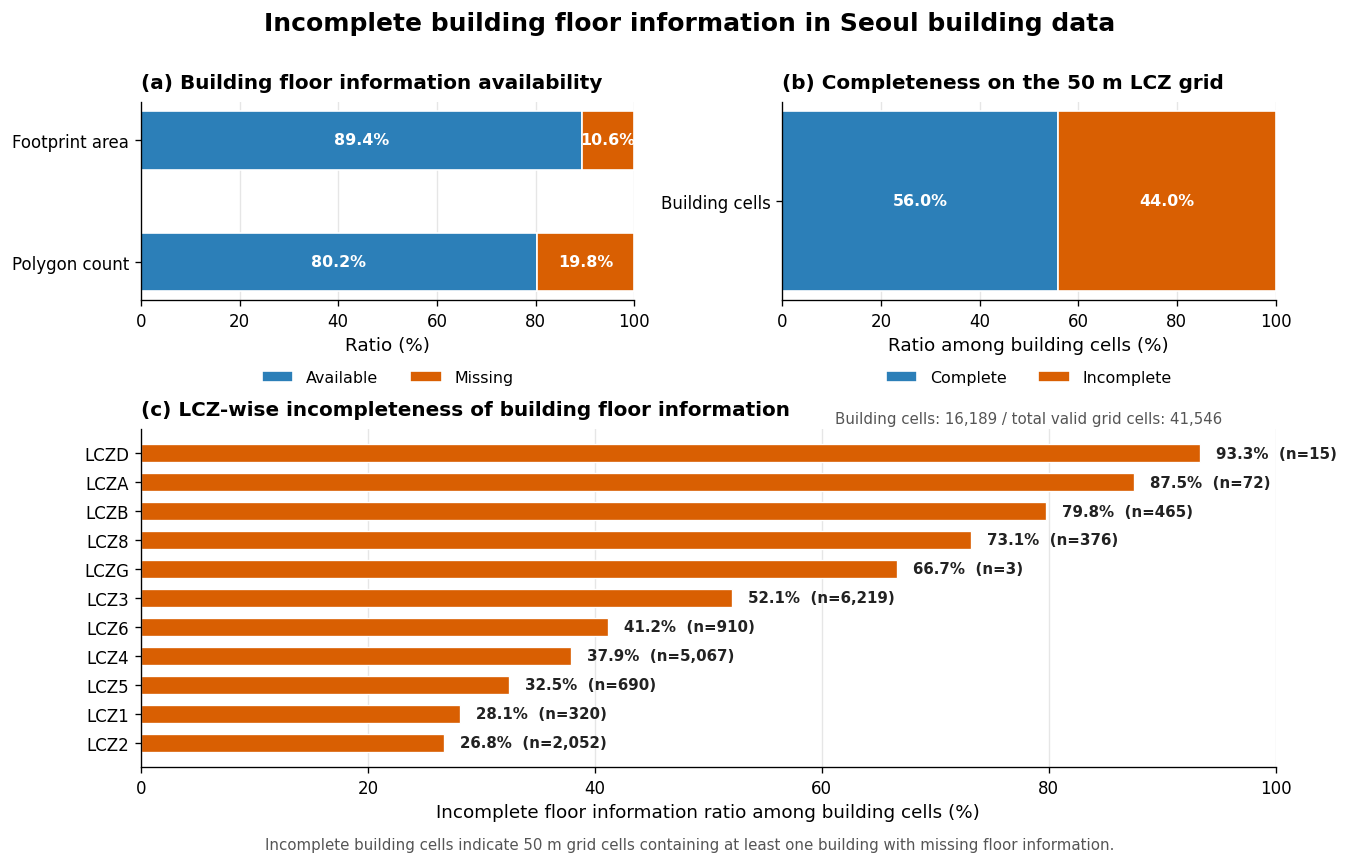

Saved outputs to: /mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness_v2


In [9]:
# ============================================================
# Paper-style visualization of incomplete building floor information
# - Use "building floor information" instead of "story"
# - One intuitive combined figure:
#   (a) polygon-level availability
#   (b) 50 m LCZ grid-level completeness among building cells
#   (c) LCZ-wise incomplete floor information ratio
# ============================================================

from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize

# ------------------------------------------------------------
# 0. Path setting
# ------------------------------------------------------------
BUILDING_SHP = Path("/mnt/disk1/workspace_jym/LCZ/data/Building/AL_11_D010_20200502/AL_11_D010_20200502.shp")
FLOOR_COL = "A10"  # building floor information column

TEMPLATE_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# LCZ-wise missingness 기준 raster
# GT 기준으로 보려면 GT 사용
LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/data/GT/seoul_LCZ.tif")

# 서울 전역 예측 map 기준으로 보고 싶으면 아래 중 하나로 변경
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw.tif")
# LCZ_TIF = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/maps/seoul_lcz_v7_full_extent_raw_maj3.tif")

OUT_DIR = Path("/mnt/disk1/workspace_jym/LCZ/work_dirs/analysis/building_floor_information_missingness_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 400

CLASS_CODES = [1, 2, 3, 4, 5, 6, 8, 101, 102, 104, 107]

LCZ_LABEL = {
    1: "LCZ1", 2: "LCZ2", 3: "LCZ3", 4: "LCZ4", 5: "LCZ5", 6: "LCZ6",
    7: "LCZ7", 8: "LCZ8", 9: "LCZ9", 10: "LCZ10",
    101: "LCZA", 102: "LCZB", 103: "LCZC", 104: "LCZD",
    105: "LCZE", 106: "LCZF", 107: "LCZG"
}

# ------------------------------------------------------------
# 1. Plot style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "axes.linewidth": 0.8,
})

COLOR_VALID = "#2C7FB8"       # blue
COLOR_MISSING = "#D95F02"     # orange
COLOR_COMPLETE = "#2C7FB8"    # blue
COLOR_INCOMPLETE = "#D95F02"  # orange
COLOR_GRAY = "#D9D9D9"
COLOR_DARK = "#222222"
COLOR_GRID = "#E6E6E6"

def save_paper_fig(fig, out_base):
    out_base = Path(out_base)
    fig.savefig(out_base.with_suffix(".png"), dpi=DPI, bbox_inches="tight", facecolor="white")
    fig.savefig(out_base.with_suffix(".svg"), bbox_inches="tight", facecolor="white")
    print("saved:", out_base.with_suffix(".png"))
    print("saved:", out_base.with_suffix(".svg"))

def pct(v):
    return f"{v:.1f}%"

def add_bar_label(ax, bar, text, color=COLOR_DARK, dx=1.0):
    w = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        w + dx,
        y,
        text,
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color=color,
    )

def add_center_text(ax, left, width, y, text, color="white", min_width=7.0):
    if width >= min_width:
        ax.text(
            left + width / 2,
            y,
            text,
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color=color,
        )

# ------------------------------------------------------------
# 2. Load building data
# ------------------------------------------------------------
print("========== Load building data ==========")

gdf = gpd.read_file(BUILDING_SHP)
gdf = gdf[gdf.geometry.notna()].copy()
gdf = gdf[~gdf.geometry.is_empty].copy()

invalid = ~gdf.geometry.is_valid
if invalid.any():
    print(f"Fix invalid geometries: {invalid.sum():,}")
    gdf.loc[invalid, "geometry"] = gdf.loc[invalid, "geometry"].buffer(0)
    gdf = gdf[gdf.geometry.notna() & (~gdf.geometry.is_empty)].copy()

# Building floor information
gdf["_floor"] = pd.to_numeric(gdf[FLOOR_COL], errors="coerce")

# Missing floor information definition:
# NaN / non-numeric / <= 0 -> missing
valid_floor = gdf["_floor"].notna() & (gdf["_floor"] > 0)
missing_floor = ~valid_floor

print(f"Total buildings: {len(gdf):,}")
print(f"Valid building floor information: {valid_floor.sum():,} ({valid_floor.mean()*100:.2f}%)")
print(f"Missing building floor information: {missing_floor.sum():,} ({missing_floor.mean()*100:.2f}%)")
print(f"CRS: {gdf.crs}")

# ------------------------------------------------------------
# 3. Polygon-level statistics
# ------------------------------------------------------------
if gdf.crs is not None and gdf.crs.is_projected:
    area_m2 = gdf.geometry.area.to_numpy(dtype=np.float64)
else:
    area_m2 = gdf.to_crs("EPSG:5186").geometry.area.to_numpy(dtype=np.float64)

total_count = len(gdf)
valid_count = int(valid_floor.sum())
missing_count = int(missing_floor.sum())

total_area = float(np.nansum(area_m2))
valid_area = float(np.nansum(area_m2[valid_floor.to_numpy()]))
missing_area = float(np.nansum(area_m2[missing_floor.to_numpy()]))

poly_summary = {
    "building_total_count": total_count,
    "building_valid_floor_count": valid_count,
    "building_missing_floor_count": missing_count,
    "building_valid_floor_ratio_count": valid_count / total_count,
    "building_missing_floor_ratio_count": missing_count / total_count,
    "building_total_area_m2": total_area,
    "building_valid_floor_area_m2": valid_area,
    "building_missing_floor_area_m2": missing_area,
    "building_valid_floor_ratio_area": valid_area / total_area,
    "building_missing_floor_ratio_area": missing_area / total_area,
    "floor_min_valid": float(gdf.loc[valid_floor, "_floor"].min()),
    "floor_median_valid": float(gdf.loc[valid_floor, "_floor"].median()),
    "floor_mean_valid": float(gdf.loc[valid_floor, "_floor"].mean()),
    "floor_p95_valid": float(gdf.loc[valid_floor, "_floor"].quantile(0.95)),
    "floor_max_valid": float(gdf.loc[valid_floor, "_floor"].max()),
}

# ------------------------------------------------------------
# 4. Rasterize building floor status to 50 m LCZ grid
# ------------------------------------------------------------
print("========== Rasterize building floor information status ==========")

with rasterio.open(TEMPLATE_TIF) as src:
    template_profile = src.profile.copy()
    template_shape = (src.height, src.width)
    template_transform = src.transform
    template_crs = src.crs
    template_arr = src.read(1)
    template_nodata = src.nodata

if gdf.crs != template_crs:
    gdf_grid = gdf.to_crs(template_crs)
else:
    gdf_grid = gdf.copy()

has_building = rasterize(
    ((geom, 1) for geom in gdf_grid.geometry),
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_valid_floor = rasterize(
    ((geom, 1) for geom in gdf_grid.loc[valid_floor].geometry),
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

has_missing_floor = rasterize(
    ((geom, 1) for geom in gdf_grid.loc[missing_floor].geometry),
    out_shape=template_shape,
    transform=template_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)

valid_template = np.ones(template_shape, dtype=bool)
if template_nodata is not None:
    valid_template &= template_arr != template_nodata

# Mutually exclusive grid status
# 0: no building
# 1: complete building cell = has building and has valid floor only
# 2: incomplete building cell = has at least one missing-floor building
status = np.zeros(template_shape, dtype=np.uint8)
status[(has_building == 1) & (has_valid_floor == 1) & (has_missing_floor == 0)] = 1
status[(has_building == 1) & (has_missing_floor == 1)] = 2

# Save status raster
status_profile = template_profile.copy()
status_profile.update(count=1, dtype="uint8", nodata=255, compress="lzw")

with rasterio.open(OUT_DIR / "building_floor_information_completeness_grid.tif", "w", **status_profile) as dst:
    dst.write(status, 1)

# Grid-level statistics
total_valid_cells = int(valid_template.sum())
no_building_cells = int(((status == 0) & valid_template).sum())
complete_building_cells = int(((status == 1) & valid_template).sum())
incomplete_building_cells = int(((status == 2) & valid_template).sum())
building_cells = complete_building_cells + incomplete_building_cells

grid_summary = {
    "grid_total_valid_cells": total_valid_cells,
    "grid_no_building_cells": no_building_cells,
    "grid_building_cells": building_cells,
    "grid_complete_building_cells": complete_building_cells,
    "grid_incomplete_building_cells": incomplete_building_cells,
    "grid_building_cell_ratio": building_cells / total_valid_cells if total_valid_cells else 0,
    "grid_complete_among_building_cells_ratio": complete_building_cells / building_cells if building_cells else 0,
    "grid_incomplete_among_building_cells_ratio": incomplete_building_cells / building_cells if building_cells else 0,
}

summary = {**poly_summary, **grid_summary}

# ------------------------------------------------------------
# 5. LCZ-wise incomplete floor information statistics
# ------------------------------------------------------------
with rasterio.open(LCZ_TIF) as src:
    lcz = src.read(1)
    lcz_nodata = src.nodata

valid_lcz = valid_template.copy()
if lcz_nodata is not None:
    valid_lcz &= lcz != lcz_nodata
valid_lcz &= lcz > 0

rows = []

for code in CLASS_CODES:
    mask = valid_lcz & (lcz == code)
    total = int(mask.sum())

    complete_cells = int((mask & (status == 1)).sum())
    incomplete_cells = int((mask & (status == 2)).sum())
    bld_cells = complete_cells + incomplete_cells

    rows.append({
        "class_code": code,
        "class_label": LCZ_LABEL.get(code, f"LCZ{code}"),
        "total_cells": total,
        "building_cells": bld_cells,
        "complete_building_cells": complete_cells,
        "incomplete_building_cells": incomplete_cells,
        "building_cell_ratio": bld_cells / total if total else 0,
        "complete_among_building_cells_ratio": complete_cells / bld_cells if bld_cells else 0,
        "incomplete_among_building_cells_ratio": incomplete_cells / bld_cells if bld_cells else 0,
    })

lcz_missing_df = pd.DataFrame(rows)

# Save tables
pd.DataFrame([summary]).to_csv(
    OUT_DIR / "building_floor_information_missingness_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

lcz_missing_df.to_csv(
    OUT_DIR / "building_floor_information_missingness_by_lcz.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(OUT_DIR / "building_floor_information_missingness_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))
display(lcz_missing_df)

# ------------------------------------------------------------
# 6. Paper-style combined figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12.2, 7.2))
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[0.85, 1.45],
    width_ratios=[1.0, 1.0],
    hspace=0.48,
    wspace=0.30,
)

# ------------------------------------------------------------
# (a) Polygon-level availability
# ------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

availability_df = pd.DataFrame({
    "Basis": ["Polygon count", "Footprint area"],
    "Valid": [
        summary["building_valid_floor_ratio_count"] * 100,
        summary["building_valid_floor_ratio_area"] * 100,
    ],
    "Missing": [
        summary["building_missing_floor_ratio_count"] * 100,
        summary["building_missing_floor_ratio_area"] * 100,
    ],
})

y = np.arange(len(availability_df))
bar_h = 0.48

ax1.barh(
    y,
    availability_df["Valid"],
    height=bar_h,
    color=COLOR_VALID,
    edgecolor="white",
    linewidth=1.0,
    label="Available",
)

ax1.barh(
    y,
    availability_df["Missing"],
    left=availability_df["Valid"],
    height=bar_h,
    color=COLOR_MISSING,
    edgecolor="white",
    linewidth=1.0,
    label="Missing",
)

for i, row in availability_df.iterrows():
    valid_pct = row["Valid"]
    missing_pct = row["Missing"]
    add_center_text(ax1, 0, valid_pct, i, pct(valid_pct), color="white", min_width=12)
    add_center_text(ax1, valid_pct, missing_pct, i, pct(missing_pct), color="white", min_width=7)

ax1.set_yticks(y, availability_df["Basis"])
ax1.set_xlim(0, 100)
ax1.set_xlabel("Ratio (%)")
ax1.set_title("(a) Building floor information availability", loc="left", fontweight="bold", pad=8)
ax1.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.50))

# ------------------------------------------------------------
# (b) Grid-level completeness among building cells
# ------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

complete_pct = summary["grid_complete_among_building_cells_ratio"] * 100
incomplete_pct = summary["grid_incomplete_among_building_cells_ratio"] * 100

ax2.barh(
    [0],
    [complete_pct],
    height=0.48,
    color=COLOR_COMPLETE,
    edgecolor="white",
    linewidth=1.0,
    label="Complete",
)

ax2.barh(
    [0],
    [incomplete_pct],
    left=[complete_pct],
    height=0.48,
    color=COLOR_INCOMPLETE,
    edgecolor="white",
    linewidth=1.0,
    label="Incomplete",
)

add_center_text(ax2, 0, complete_pct, 0, pct(complete_pct), color="white", min_width=12)
add_center_text(ax2, complete_pct, incomplete_pct, 0, pct(incomplete_pct), color="white", min_width=7)

ax2.text(
    50,
    -0.58,
    f"Building cells: {building_cells:,} / total valid grid cells: {total_valid_cells:,}",
    ha="center",
    va="center",
    fontsize=9,
    color="#555555",
)

ax2.set_yticks([0], ["Building cells"])
ax2.set_xlim(0, 100)
ax2.set_xlabel("Ratio among building cells (%)")
ax2.set_title("(b) Completeness on the 50 m LCZ grid", loc="left", fontweight="bold", pad=8)
ax2.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.50))

# ------------------------------------------------------------
# (c) LCZ-wise incomplete floor information ratio
# ------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, :])

plot_df = lcz_missing_df[lcz_missing_df["building_cells"] > 0].copy()
plot_df["incomplete_pct"] = plot_df["incomplete_among_building_cells_ratio"] * 100

# 직관성을 위해 누락률 높은 순으로 정렬
plot_df = plot_df.sort_values("incomplete_pct", ascending=True)

labels = plot_df["class_label"].tolist()
values = plot_df["incomplete_pct"].to_numpy()
counts = plot_df["building_cells"].to_numpy()

y = np.arange(len(plot_df))
bars = ax3.barh(
    y,
    values,
    height=0.62,
    color=COLOR_INCOMPLETE,
    edgecolor="white",
    linewidth=0.8,
)

ax3.set_yticks(y, labels)
ax3.set_xlim(0, max(10, min(100, values.max() * 1.18)))
ax3.set_xlabel("Incomplete floor information ratio among building cells (%)")
ax3.set_title("(c) LCZ-wise incompleteness of building floor information", loc="left", fontweight="bold", pad=8)
ax3.grid(axis="x", color=COLOR_GRID, linewidth=0.8)
ax3.set_axisbelow(True)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

for bar, v, n in zip(bars, values, counts):
    ax3.text(
        bar.get_width() + max(values.max() * 0.015, 0.8),
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%  (n={int(n):,})",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color=COLOR_DARK,
    )

fig.suptitle(
    "Incomplete building floor information in Seoul building data",
    fontsize=15,
    fontweight="bold",
    y=0.985,
)

fig.text(
    0.5,
    0.012,
    "Incomplete building cells indicate 50 m grid cells containing at least one building with missing floor information.",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#555555",
)

plt.tight_layout(rect=[0.02, 0.04, 0.98, 0.95])

out_base = OUT_DIR / "building_floor_information_missingness_paper_v2"
save_paper_fig(fig, out_base)
plt.show()

print("Saved outputs to:", OUT_DIR)